<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/Cross_Sectional_Stock_Ranking_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr

In [ ]:
# --- 1. DEFINE UNIVERSE ---
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'TSLA', 'META', 'JPM', 'KO', 'XOM']
print(f"Downloading data for {len(tickers)} tickers...")

data = yf.download(tickers, start='2018-01-01', end='2024-01-01', group_by='ticker', progress=False)
data.head()

/tmp/ipython-input-1753666816.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2018-01-01', end='2024-01-01', group_by='ticker', progress=False)


Ticker            JPM                                                 NVDA  \
Price            Open       High        Low      Close    Volume      Open   
Date                                                                         
2018-01-02  86.084961  86.396892  85.429106  86.340904  13578800  4.840271   
2018-01-03  86.268924  86.772811  85.964994  86.428886  11901000  5.045966   
2018-01-04  87.120317  88.462978  86.991676  87.667030  12953700  5.334238   
2018-01-05  87.843900  88.077058  86.653993  87.104225  14155000  5.295423   
2018-01-08  86.951469  87.377583  86.589670  87.232864  12466500  5.448953   

Ticker                                               ...         KO  \
Price           High       Low     Close     Volume  ...       Open   
Date                                                 ...              
2018-01-02  4.932241  4.808626  4.928533  355616000  ...  35.781105   
2018-01-03  5.283307  5.037313  5.252898  914704000  ...  35.453774   
2018-01-04  5.390854  5.258338  5.280589  583268000  ...  35.508310   
2018-01-05  5.362669  5.218534  5.325338  580124000  ...  35.866832   
2018-01-08  5.562679  5.403957  5.488510  881216000  ...  35.812274   

Ticker                                                      MSFT             \
Price            High        Low      Close    Volume       Open       High   
Date                                                                          
2018-01-02  35.804485  35.469354  35.492737  10872200  79.215935  79.381486   
2018-01-03  35.609646  35.336866  35.414803  12635600  79.151568  79.565449   
2018-01-04  36.022698  35.422579  35.913586  12709400  79.638995  80.623108   
2018-01-05  36.007119  35.687576  35.905800  13113100  80.623127  81.312921   
2018-01-08  35.929178  35.757718  35.851242   7068600  81.119772  81.469272   

Ticker                                      
Price             Low      Close    Volume  
Date                                        
2018-01-02  78.636511  79.050385  22483800  
2018-01-03  79.068796  79.418289  26061400  
2018-01-04  79.620604  80.117256  21912000  
2018-01-05  80.411587  81.110580  23407100  
2018-01-08  80.567938  81.193352  22113000  

[5 rows x 50 columns]

In [ ]:
# Reformat: We want a MultiIndex DataFrame (Date, Ticker) -> Columns: Open, High, Low, Close
# yfinance gives us levels like ('AAPL', 'Close'). We need to stack this.
df_list = []
for t in tickers:
    temp = data[t].copy()
    temp['Ticker'] = t
    df_list.append(temp)

df = pd.concat(df_list)
df.reset_index(inplace=True)
df.set_index(['Date', 'Ticker'], inplace=True)
df.sort_index(inplace=True)

print("Data Structure (MultiIndex):")
df.head()

Data Structure (MultiIndex):


Price                   Open       High        Low      Close     Volume
Date       Ticker                                                       
2018-01-02 AAPL    39.850095  40.351266  39.639320  40.341896  102223600
           AMZN    58.599998  59.500000  58.525501  59.450500   53890000
           GOOGL   52.256170  53.395560  52.256170  53.258099   31766000
           JPM     86.084961  86.396892  85.429106  86.340904   13578800
           KO      35.781105  35.804485  35.469354  35.492737   10872200

In [ ]:
# --- 2. FEATURE ENGINEERING ---

# A. Raw Features (Time Series calculation first)
# We compute these per ticker (groupby Ticker)
df['Ret_1d'] = df.groupby('Ticker')['Close'].pct_change()
df['Ret_20d'] = df.groupby('Ticker')['Close'].pct_change(20)
df['Vol_20'] = df.groupby('Ticker')['Ret_1d'].rolling(20).std().reset_index(0, drop=True)
df['Mom_126'] = df.groupby('Ticker')['Close'].pct_change(126) # 6-month momentum

# Target: Next Day Return
df['Target_Ret'] = df.groupby('Ticker')['Ret_1d'].shift(-1)

# Drop NaNs before ranking
df.dropna(inplace=True)
df.head()

Price                   Open       High        Low      Close    Volume  \
Date       Ticker                                                         
2018-07-03 AAPL    44.328473  44.366243  43.325246  43.414948  55819200   
           AMZN    86.197998  86.250000  84.624001  84.697998  43546000   
           GOOGL   57.040022  57.064337  55.303642  55.395447  16448000   
           JPM     85.178323  85.477304  83.651071  83.723801   8311700   
           KO      34.950929  35.165109  34.895401  34.895401   8214300   

Price                Ret_1d   Ret_20d    Vol_20   Mom_126  Target_Ret  
Date       Ticker                                                      
2018-07-03 AAPL   -0.017416 -0.048575  0.008504  0.076175    0.008047  
           AMZN   -0.011565 -0.001409  0.012396  0.424681    0.003406  
           GOOGL  -0.022616 -0.030182  0.011762  0.040132    0.022405  
           JPM    -0.013989 -0.039225  0.010423 -0.030311    0.006502  
           KO      0.005486  0.029501  0.007288 -0.016830    0.015230

In [ ]:
# B. CROSS-SECTIONAL RANKING (The "Alpha" Step)
# We want to know: "How is this stock's Momentum compared to PEERS on this specific day?"

features = ['Ret_20d', 'Vol_20', 'Mom_126']

for feat in features:
    # 1. Z-Score: (Value - Mean) / Std  <-- Calculated PER DAY across all tickers
    # This removes the market trend. If all stocks are up, the mean is high, so Z-scores stay relative.
    df[f'{feat}_Z'] = df.groupby('Date')[feat].transform(lambda x: (x - x.mean()) / x.std())

    # 2. Rank: Simple 0 to 1 percentile rank
    # Useful if data has outliers
    df[f'{feat}_Rank'] = df.groupby('Date')[feat].transform(lambda x: x.rank(pct=True))

# Target Ranking: We want to predict the RELATIVE performance
df['Target_Rank'] = df.groupby('Date')['Target_Ret'].transform(lambda x: x.rank(pct=True))

df.dropna(inplace=True)

# Check what we just did
print("\nExample of Cross-Sectional Data (Single Day):")
df.xs(df.index.get_level_values('Date')[-1]).head()


Example of Cross-Sectional Data (Single Day):


Price,Open,High,Low,Close,Volume,Ret_1d,Ret_20d,Vol_20,Mom_126,Target_Ret,Ret_20d_Z,Ret_20d_Rank,Vol_20_Z,Vol_20_Rank,Mom_126_Z,Mom_126_Rank,Target_Rank
Ticker,,,,,,,,,,,,,,,,,
AAPL,192.323710,192.838849,191.362784,191.768951,34049900,0.002226,0.022232,0.008973,0.023771,-0.005424,-0.326987,0.4,-0.786212,0.3,-0.791043,0.4,0.4
AMZN,153.720001,154.080002,152.949997,153.380005,27057000,0.000261,0.048250,0.011678,0.199218,-0.009388,0.373125,0.8,-0.223299,0.5,0.732672,0.7,0.3
GOOGL,139.724284,140.081585,138.702010,139.178406,16045700,-0.000997,0.038818,0.016675,0.177414,-0.003851,0.119308,0.7,0.816917,0.8,0.543308,0.6,0.5
JPM,161.244262,162.491558,160.911009,162.148788,6320100,0.005313,0.103551,0.006972,0.204314,-0.001174,1.861160,1.0,-1.202807,0.1,0.776931,0.8,0.7
KO,55.280857,55.488216,55.167747,55.375111,8400100,0.000681,0.016964,0.007891,-0.005538,0.003064,-0.468734,0.3,-1.011462,0.2,-1.045585,0.3,1.0


In [ ]:
# --- 3. TRAINING ---
# We predict the Target_Rank (0 to 1).
# 0.99 = Best performing stock tomorrow. 0.01 = Worst.

feature_cols = [f'{f}_Z' for f in features] # We use Z-scores for the model inputs
target_col = 'Target_Rank'

# Train/Test Split (Time-based)
dates = df.index.get_level_values('Date').unique().sort_values()
split_idx = int(len(dates) * 0.8)
split_date = dates[split_idx]

train_df = df[df.index.get_level_values('Date') < split_date]
test_df = df[df.index.get_level_values('Date') >= split_date]

model = Ridge(alpha=1.0)
model.fit(train_df[feature_cols], train_df[target_col])

Ridge()

In [ ]:
# Predictions
test_df['Pred_Rank'] = model.predict(test_df[feature_cols])
test_df.head()

/tmp/ipython-input-1743654901.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Pred_Rank'] = model.predict(test_df[feature_cols])


Price                    Open        High         Low       Close    Volume  \
Date       Ticker                                                             
2022-11-21 AAPL    147.928312  148.135183  145.524574  145.810257  58724100   
           AMZN     93.970001   95.019997   90.589996   92.459999  84330300   
           GOOGL    96.560416   97.662093   94.644889   94.883087  21647400   
           JPM     123.652791  124.410936  122.737456  123.014832   7800500   
           KO       55.716857   56.442691   55.526326   56.324745  15399400   

Price                Ret_1d   Ret_20d    Vol_20   Mom_126  Target_Ret  \
Date       Ticker                                                       
2022-11-21 AAPL   -0.021680 -0.007992  0.033646  0.037394    0.014661   
           AMZN   -0.017846 -0.228343  0.041161 -0.140363    0.008003   
           GOOGL  -0.018783 -0.067499  0.037482 -0.142509    0.015167   
           JPM    -0.005903  0.087188  0.013178  0.086901    0.014957   
           KO      0.015375  0.078340  0.013000  0.001979    0.004349   

Price              Ret_20d_Z  Ret_20d_Rank  Vol_20_Z  Vol_20_Rank  Mom_126_Z  \
Date       Ticker                                                              
2022-11-21 AAPL     0.120483           0.6 -0.027962          0.5   0.651127   
           AMZN    -1.441222           0.1  0.407892          0.8  -0.328622   
           GOOGL   -0.301263           0.4  0.194543          0.6  -0.340449   
           JPM      0.795060           0.9 -1.215037          0.2   0.923995   
           KO       0.732351           0.8 -1.225328          0.1   0.455929   

Price              Mom_126_Rank  Target_Rank  Pred_Rank  
Date       Ticker                                        
2022-11-21 AAPL             0.8          0.6   0.555282  
           AMZN             0.4          0.2   0.547195  
           GOOGL            0.3          0.8   0.546938  
           JPM              0.9          0.7   0.560025  
           KO               0.7          0.1   0.556289


Mean Information Coefficient (IC): 0.0103


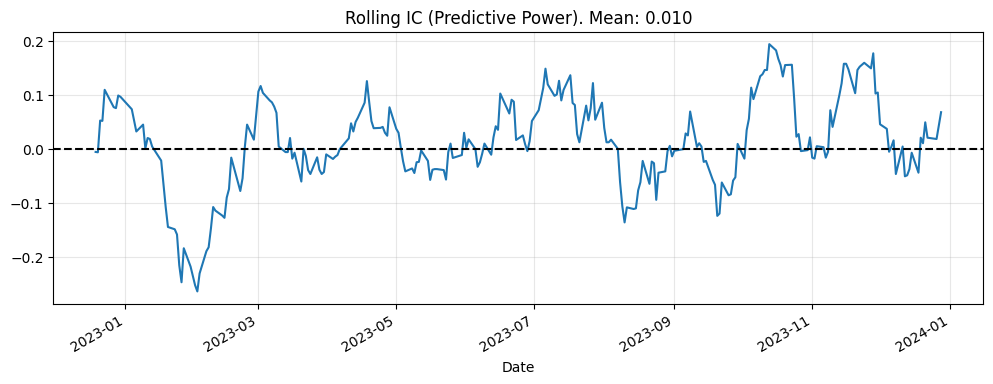

In [ ]:
# --- 4. EVALUATION: INFORMATION COEFFICIENT (IC) ---
# IC is the correlation between our Predicted Rank and the Actual Rank.
# IC > 0.05 is considered very good in finance.

def calc_ic(group):
    return spearmanr(group['Pred_Rank'], group['Target_Rank'])[0]

ic_series = test_df.groupby('Date').apply(calc_ic)
mean_ic = ic_series.mean()
print(f"\nMean Information Coefficient (IC): {mean_ic:.4f}")

plt.figure(figsize=(12, 4))
ic_series.rolling(20).mean().plot(title=f"Rolling IC (Predictive Power). Mean: {mean_ic:.3f}")
plt.axhline(0, color='black', linestyle='--')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- 5. STRATEGY BACKTEST (Long/Short) ---

# Define Strategy Logic
def daily_strategy(group):
    # Sort by prediction
    group = group.sort_values('Pred_Rank', ascending=False)

    # Top 2 Long (Weight +0.5 each)
    longs = group.iloc[:2]
    long_ret = longs['Target_Ret'].mean()

    # Bottom 2 Short (Weight -0.5 each)
    shorts = group.iloc[-2:]
    short_ret = -1 * shorts['Target_Ret'].mean() # Multiply by -1 for shorting

    # Net Return
    return (long_ret + short_ret) / 2

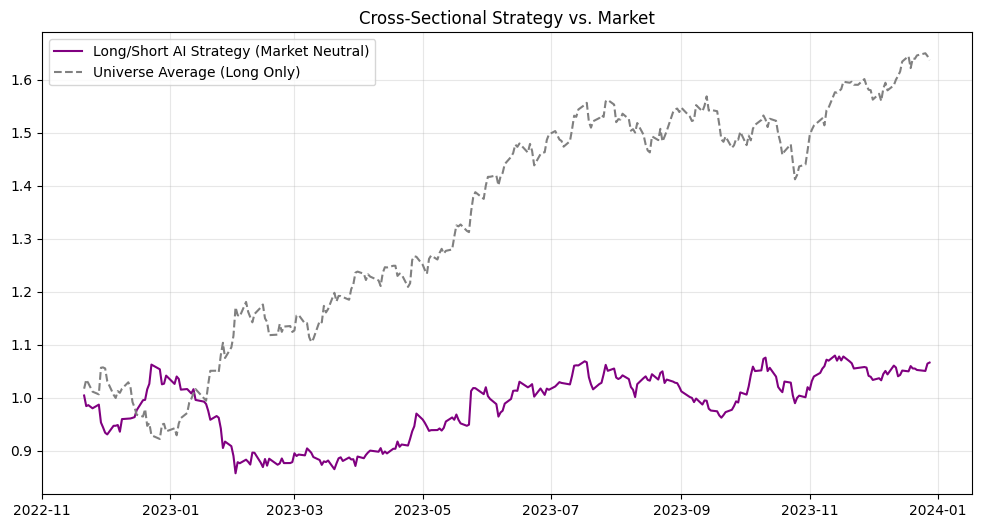


What drives the ranking?


,Feature,Weight
2,Mom_126_Z,0.008117
0,Ret_20d_Z,-0.000605
1,Vol_20_Z,-0.002474


In [ ]:
# Apply strategy per day
strat_returns = test_df.groupby('Date').apply(daily_strategy)
cumulative_ret = (1 + strat_returns).cumprod()

# Compare to Market (Equal Weight Universe)
market_returns = test_df.groupby('Date')['Target_Ret'].mean()
cumulative_mkt = (1 + market_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_ret, label='Long/Short AI Strategy (Market Neutral)', color='purple')
plt.plot(cumulative_mkt, label='Universe Average (Long Only)', color='gray', linestyle='--')
plt.title("Cross-Sectional Strategy vs. Market")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Coefficients
coef_df = pd.DataFrame({'Feature': feature_cols, 'Weight': model.coef_})
print("\nWhat drives the ranking?")
coef_df.sort_values(by='Weight', ascending=False)

# Quantamental Ranking Engine

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import xgboost as xgb
from xgboost import XGBRanker
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

In [ ]:
# --- 1. DATA INGESTION (The Universe) ---
# We use a mix of Tech, Energy, and Defensive to get diverse behaviors
tickers = ['NVDA', 'AMD', 'MSFT', 'GOOGL', 'XOM', 'CVX', 'KO', 'PEP', 'JPM', 'BAC']
print(f"Downloading data for {len(tickers)} tickers...")

data = yf.download(tickers, start='2015-01-01', end='2024-01-01', group_by='ticker', progress=False)

# Stack MultiIndex into Long Format
df_list = []
for t in tickers:
    temp = data[t].copy()
    temp['Ticker'] = t
    df_list.append(temp)

df = pd.concat(df_list)
df.reset_index(inplace=True)
df.set_index(['Date', 'Ticker'], inplace=True)
df.sort_index(inplace=True)
df.head()

/tmp/ipython-input-2863486793.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2015-01-01', end='2024-01-01', group_by='ticker', progress=False)


Price                   Open       High        Low      Close    Volume
Date       Ticker                                                      
2015-01-02 AMD      2.670000   2.670000   2.670000   2.670000         0
           BAC     14.275059  14.306800  14.029074  14.203644  48951100
           CVX     69.617079  70.471470  69.130640  70.209541   5898800
           GOOGL   26.430301  26.589102  26.196070  26.278946  26480000
           JPM     46.280406  46.860957  46.198533  46.511139  12600000

In [ ]:
# --- 2. QUANTAMENTAL FEATURE ENGINEERING ---

# A. Technicals (Momentum & Risk)
df['Ret_1d'] = df.groupby('Ticker')['Close'].pct_change()
df['Vol_20'] = df.groupby('Ticker')['Ret_1d'].rolling(20).std().reset_index(0, drop=True)
df['Mom_3M'] = df.groupby('Ticker')['Close'].pct_change(63)

# B. "Fundamental" Proxies (Simulating Value & Quality)
# Proxy 1: "Deep Value" (Distance from Long-Term Trend)
# Similar to P/B ratio: If price is way below 2-year average, it's "Cheap" (or dying).
df['LT_Trend'] = df.groupby('Ticker')['Close'].transform(lambda x: x.rolling(500).mean())
df['Value_Score'] = (df['Close'] / df['LT_Trend']) # Low score = "Undervalued" relative to trend

# Proxy 2: "Quality/Efficiency" (Kaufman Ratio from previous lesson)
# High Efficiency = Stock moves up in a straight line (Institutional Accumulation)
# This mimics "Earnings Quality"
change = df.groupby('Ticker')['Close'].diff(63).abs()
vol_sum = df.groupby('Ticker')['Close'].diff().abs().rolling(63).sum()
df['Quality_Score'] = change / vol_sum

# Target: 5-Day Forward Return (Swing Trading Horizon)
# We want to predict the rank of returns 1 week from now
df['Target_Ret'] = df.groupby('Ticker')['Close'].pct_change(5).shift(-5)

# Drop NaNs
df.dropna(inplace=True)
df.head()

Price                   Open       High        Low      Close    Volume  \
Date       Ticker                                                         
2016-12-23 AMD     11.300000  11.600000  11.260000  11.580000  32288200   
           BAC     18.362879  18.477086  18.297618  18.436298  38187800   
           CVX     80.631416  80.828887  80.386273  80.638222   2682900   
           GOOGL   40.097532  40.244421  39.953619  40.087109  15310000   
           JPM     68.032249  68.149547  67.563062  68.071350  10759400   

Price                Ret_1d    Vol_20    Mom_3M   LT_Trend  Value_Score  \
Date       Ticker                                                         
2016-12-23 AMD    -0.001724  0.032918  0.832278   3.730580     3.104075   
           BAC     0.002662  0.017928  0.503237  12.817625     1.438355   
           CVX    -0.002947  0.008686  0.210827  63.878741     1.262364   
           GOOGL  -0.002322  0.009721  0.006416  34.276708     1.169515   
           JPM     0.001841  0.009080  0.332970  49.251483     1.382118   

Price              Quality_Score  Target_Ret  
Date       Ticker                             
2016-12-23 AMD          0.289522   -0.003354  
           BAC          0.356068    0.015088  
           CVX          0.864802    0.093318  
           GOOGL        0.015954   -0.007367  
           JPM          1.080006   -0.005155

In [ ]:
# --- 3. CROSS-SECTIONAL RANKING (Normalization) ---
# Crucial: XGBRanker needs to know "What is High?" relative to TODAY'S market.

features = ['Vol_20', 'Mom_3M', 'Value_Score', 'Quality_Score']

for feat in features:
    # Convert raw numbers to Z-Scores per Day
    # This makes the data "Market Neutral" before the model even sees it
    df[f'{feat}_Z'] = df.groupby('Date')[feat].transform(lambda x: (x - x.mean()) / x.std())

# Create the Target Rank (0 to 1) per day
df['Target_Rank'] = df.groupby('Date')['Target_Ret'].rank(pct=True)
df.head()

Price                   Open       High        Low      Close    Volume  \
Date       Ticker                                                         
2016-12-23 AMD     11.300000  11.600000  11.260000  11.580000  32288200   
           BAC     18.362879  18.477086  18.297618  18.436298  38187800   
           CVX     80.631416  80.828887  80.386273  80.638222   2682900   
           GOOGL   40.097532  40.244421  39.953619  40.087109  15310000   
           JPM     68.032249  68.149547  67.563062  68.071350  10759400   

Price                Ret_1d    Vol_20    Mom_3M   LT_Trend  Value_Score  \
Date       Ticker                                                         
2016-12-23 AMD    -0.001724  0.032918  0.832278   3.730580     3.104075   
           BAC     0.002662  0.017928  0.503237  12.817625     1.438355   
           CVX    -0.002947  0.008686  0.210827  63.878741     1.262364   
           GOOGL  -0.002322  0.009721  0.006416  34.276708     1.169515   
           JPM     0.001841  0.009080  0.332970  49.251483     1.382118   

Price              Quality_Score  Target_Ret  Vol_20_Z  Mom_3M_Z  \
Date       Ticker                                                  
2016-12-23 AMD          0.289522   -0.003354  2.243864  1.803678   
           BAC          0.356068    0.015088  0.442270  0.728670   
           CVX          0.864802    0.093318 -0.668438 -0.226659   
           GOOGL        0.015954   -0.007367 -0.544039 -0.894489   
           JPM          1.080006   -0.005155 -0.621168  0.172393   

Price              Value_Score_Z  Quality_Score_Z  Target_Rank  
Date       Ticker                                               
2016-12-23 AMD          1.999812        -0.177746          0.3  
           BAC         -0.176576         0.005031          0.7  
           CVX         -0.406522         1.402322          0.9  
           GOOGL       -0.527837        -0.929128          0.1  
           JPM         -0.250055         1.993403          0.2

In [ ]:
# --- 4. PREPARING DATA FOR XGBRANKER ---
# XGBRanker requires data sorted by Query ID (Date) and a "Group" array
# telling it how many items are in each query.

df = df.sort_index(level='Date') # Must be sorted by group

# Split Train/Test
dates = df.index.get_level_values('Date').unique()
split_idx = int(len(dates) * 0.8)
split_date = dates[split_idx]

train_df = df[df.index.get_level_values('Date') < split_date]
test_df = df[df.index.get_level_values('Date') >= split_date]

# Create "Group" arrays (Number of stocks per day)
# e.g., [10, 10, 10...] if we have 10 stocks every day
train_groups = train_df.groupby('Date').size().to_numpy()
test_groups = test_df.groupby('Date').size().to_numpy()

X_train = train_df[[f'{f}_Z' for f in features]]
y_train = train_df['Target_Rank']

X_test = test_df[[f'{f}_Z' for f in features]]
y_test = test_df['Target_Rank']

In [ ]:
# --- 5. TRAINING XGBRANKER ---

# CONVERSION STEP: Turn the 0-1 float rank into discrete integer "bins" (0 to 9)
# XGBRanker requires non-negative integers for pairwise ranking.
y_train_int = (y_train * 10).astype(int).clip(0, 9)
y_test_int = (y_test * 10).astype(int).clip(0, 9)

ranker = XGBRanker(
    objective='rank:pairwise',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

# Use the new integer targets (y_train_int, y_test_int)
ranker.fit(
    X_train, y_train_int,
    group=train_groups,
    eval_set=[(X_test, y_test_int)],
    eval_group=[test_groups],
    verbose=False
)

# Predict stays the same - it will still output a continuous "relevance score"
test_df['Pred_Score'] = ranker.predict(X_test)

/tmp/ipython-input-281185402.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Pred_Score'] = ranker.predict(X_test)


Mean IC: -0.0047


<Figure size 1000x500 with 0 Axes>

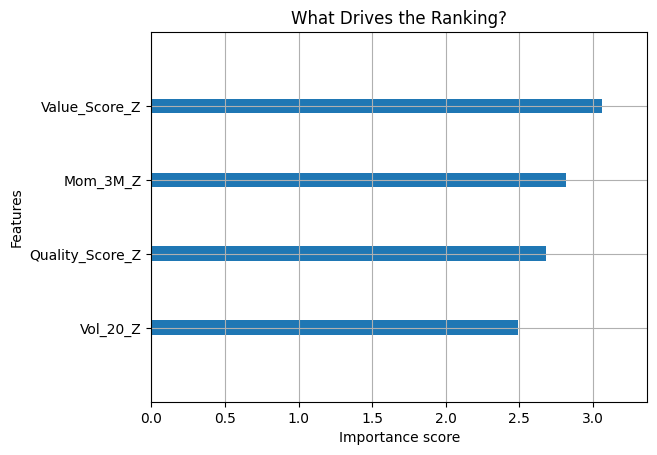

In [ ]:
# --- 6. EVALUATION ---

# A. Information Coefficient (IC)
def calc_ic(group):
    return spearmanr(group['Pred_Score'], group['Target_Rank'])[0]

ic_series = test_df.groupby('Date').apply(calc_ic)
print(f"Mean IC: {ic_series.mean():.4f}")

# B. Feature Importance
plt.figure(figsize=(10, 5))
xgb.plot_importance(ranker, importance_type='gain', show_values=False, title='What Drives the Ranking?')
plt.show()

In [ ]:
# --- 7. BACKTESTING THE RANKER ---

# We resample to weekly because our target was 5-day returns
# We take the mean prediction for the week to smooth noise
weekly_preds = test_df.groupby(['Ticker', pd.Grouper(level='Date', freq='W-FRI')])['Pred_Score'].last()
weekly_ret = test_df.groupby(['Ticker', pd.Grouper(level='Date', freq='W-FRI')])['Target_Ret'].last() # Actually next week's return

backtest_df = pd.DataFrame({'Pred': weekly_preds, 'Ret': weekly_ret}).dropna()

def weekly_strategy(group):
    # Sort by Prediction
    group = group.sort_values('Pred', ascending=False)

    if len(group) < 6: return 0 # Need at least 6 stocks to trade

    # Long Top 3
    longs = group.iloc[:3]
    long_ret = longs['Ret'].mean()

    # Short Bottom 3
    shorts = group.iloc[-3:]
    short_ret = -1 * shorts['Ret'].mean()

    return (long_ret + short_ret) / 2

portfolio_returns = backtest_df.groupby('Date').apply(weekly_strategy)
cum_perf = (1 + portfolio_returns).cumprod()

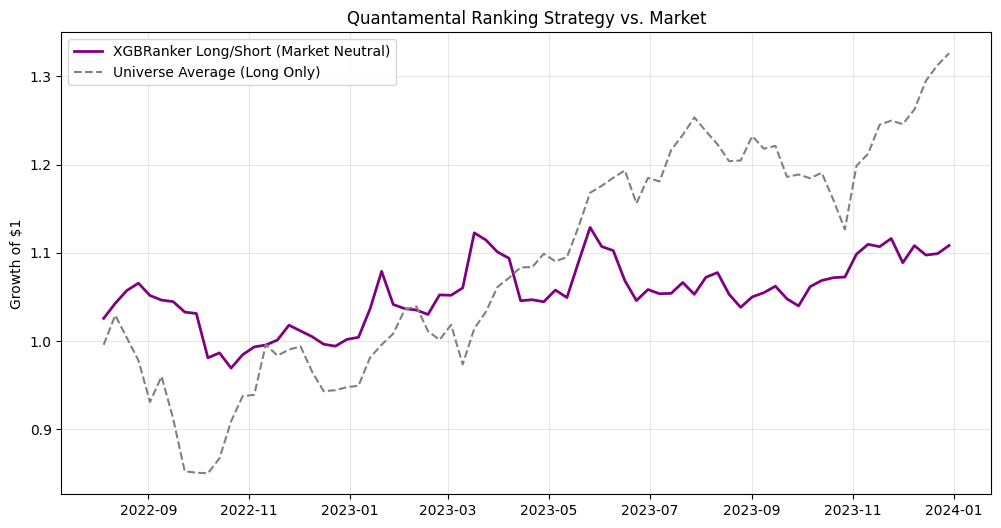

In [ ]:
# Benchmark (Equal Weight Universe)
benchmark = backtest_df.groupby('Date')['Ret'].mean()
cum_bench = (1 + benchmark).cumprod()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(cum_perf, label='XGBRanker Long/Short (Market Neutral)', color='purple', linewidth=2)
plt.plot(cum_bench, label='Universe Average (Long Only)', color='gray', linestyle='--')
plt.title("Quantamental Ranking Strategy vs. Market")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Market Neutral Strategy. Beats S&P500 in a bear market.